# Research questions — video game pricing (Steam)

This notebook collects the pricing-focused questions from our P1–P3 exploration and adds **price distribution** and **price vs. release year** views. Place `cleaned_games_dataset.csv` or `steam_games_small.csv` in this folder (same as the other assignment notebooks) before running.

In [15]:
from pathlib import Path

import sys

import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")


def load_games() -> pd.DataFrame:
    """Match P1/P2/P3: CSV next to this notebook or cwd."""
    here = Path.cwd()
    candidates = [
        here / "cleaned_games_dataset.csv",
        here / "steam_games_small.csv",
        here / "Project Assignments" / "cleaned_games_dataset.csv",
        here / "Project Assignments" / "steam_games_small.csv",
    ]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path)
    raise FileNotFoundError(
        "Could not find cleaned_games_dataset.csv or steam_games_small.csv. "
        "Copy one into Project Assignments/ (same folder as this notebook)."
    )


def prepare_prices(df: pd.DataFrame) -> pd.DataFrame:
    """Cents → dollars; missing prices for free games → 0 (P1/P2 pattern)."""
    out = df.copy()
    for c in ("mat_initial_price", "mat_final_price"):
        if c not in out.columns:
            raise ValueError(f"Expected column {c} in dataset")
        out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0) / 100.0
    return out


def categorize_initial_price(price: float) -> str:
    """P1 small-multiples buckets on initial price (USD)."""
    if price == 0:
        return "Free"
    if price <= 10:
        return "Low"
    if price <= 40:
        return "Medium"
    return "High"


raw = load_games()
games = prepare_prices(raw)
if "is_free" in games.columns:
    games["is_free"] = games["is_free"].map(lambda x: str(x).lower() in ("true", "1", "yes"))
games["price_category_initial"] = games["mat_initial_price"].apply(categorize_initial_price)

games["price_category_final"] = pd.cut(
    games["mat_final_price"],
    bins=[0, 10, 30, 60, np.inf],
    labels=["Low ($0–10)", "Mid ($10–30)", "High ($30–60)", "Premium ($60+)"],
    include_lowest=True,
)

if "release_date" in games.columns:
    games["release_year"] = pd.to_datetime(games["release_date"], errors="coerce").dt.year
elif "release_year" in games.columns:
    games["release_year"] = pd.to_numeric(games["release_year"], errors="coerce")
else:
    games["release_year"] = np.nan

games.head()

ModuleNotFoundError: No module named 'plotly'

## Data quality choices that affect price plots

**Question:** What missingness and scale issues do we need to fix before interpreting prices?

We summarize missing counts (raw file, cents) and show how many rows remain after the same caps used elsewhere for readability.

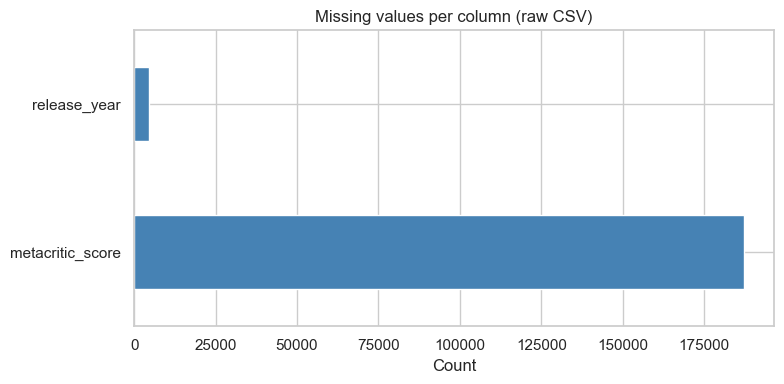

In [ ]:
missing = raw.isna().sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
missing[missing > 0].plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Missing values per column (raw CSV)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

## Game price distributions

**Question:** How are **initial** and **final** Steam prices distributed after converting cents to dollars and treating free titles as \$0?

Histograms are capped at \$100 on the x-axis for the bulk of the market (extreme list prices omitted from the view).

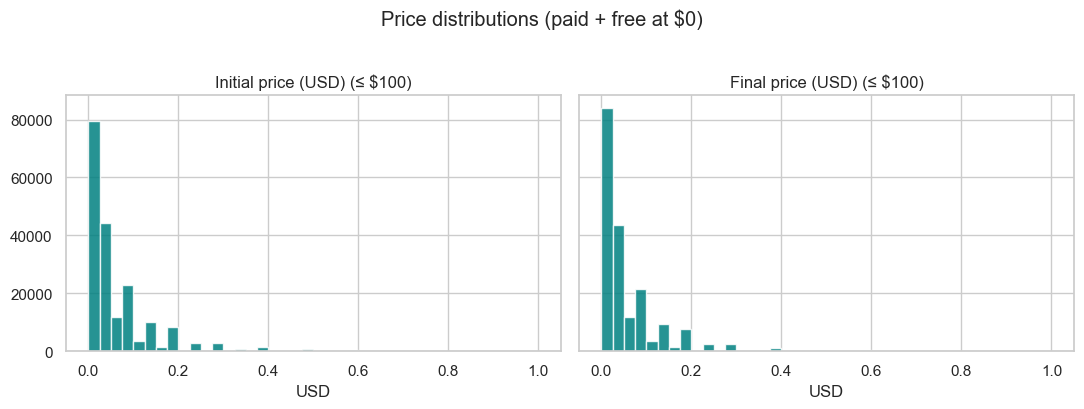

In [ ]:
cap = 100
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col, title in zip(
    axes,
    ["mat_initial_price", "mat_final_price"],
    ["Initial price (USD)", "Final price (USD)"],
):
    s = games.loc[games[col] <= cap, col]
    ax.hist(s, bins=40, color="teal", edgecolor="white", alpha=0.85)
    ax.set_title(title + f" (≤ ${cap})")
    ax.set_xlabel("USD")
fig.suptitle("Price distributions (paid + free at $0)", y=1.02)
plt.tight_layout()
plt.show()

## Game prices over release year

**Question:** How do **typical final prices** change by **calendar year** of release?

We plot the **median** (and **mean**) `mat_final_price` by `release_year`, restricting to years with at least 30 games so single-title years do not dominate.

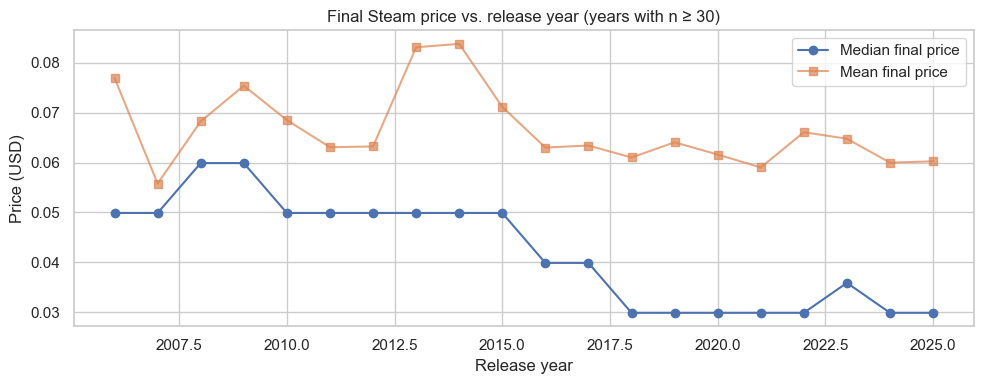

In [ ]:
gy = (
    games.dropna(subset=["release_year"])
    .assign(release_year=lambda d: pd.to_numeric(d["release_year"], errors="coerce").astype("Int64"))
    .dropna(subset=["release_year"])
    .assign(release_year=lambda d: d["release_year"].astype(int))
    .query("release_year >= 1998 & release_year <= 2026")
    .groupby("release_year")
    .agg(median_final=("mat_final_price", "median"), mean_final=("mat_final_price", "mean"), n=("mat_final_price", "size"))
    .query("n >= 30")
    .reset_index()
)

if gy.empty:
    print("Skipping year plot: need release_date or release_year with enough rows per year.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(gy["release_year"], gy["median_final"], marker="o", label="Median final price")
    ax.plot(gy["release_year"], gy["mean_final"], marker="s", alpha=0.7, label="Mean final price")
    ax.set_xlabel("Release year")
    ax.set_ylabel("Price (USD)")
    ax.set_title("Final Steam price vs. release year (years with n ≥ 30)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Initial price vs. recommendations (free vs paid, sized by final price)

**Question:** How does popularity relate to **starting** price, and how do **free vs paid** and **final price** modulate that pattern? *(P1-style `relplot`.)*

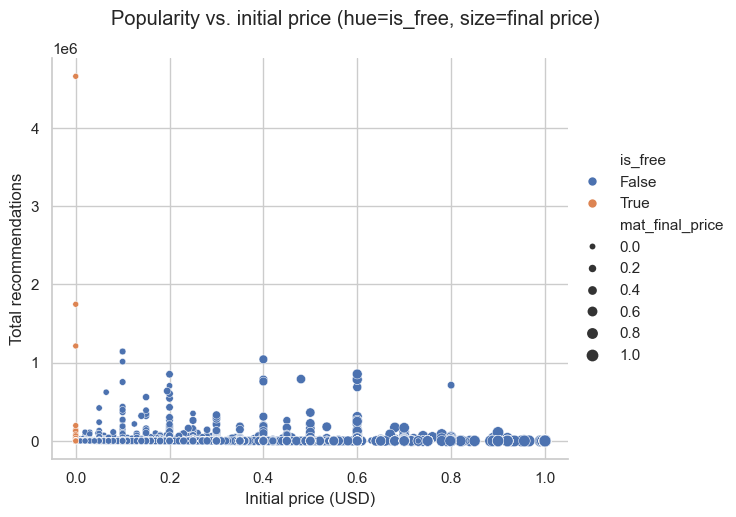

In [ ]:
q5 = sns.relplot(
    data=games,
    x="mat_initial_price",
    y="recommendations_total",
    hue="is_free",
    size="mat_final_price",
    kind="scatter",
    height=5,
    aspect=1.2,
)
q5.set_axis_labels("Initial price (USD)", "Total recommendations")
q5.fig.suptitle("Popularity vs. initial price (hue=is_free, size=final price)", y=1.03)
plt.show()

## Interactive: initial price vs. recommendations

**Question:** Same exploration as the static `relplot` above—**initial price** vs. **recommendations**, colored by **free vs paid**—but with **Plotly** so you can **hover** (see game name and other fields), **zoom**, and **pan** (matches the spirit of P2/P3 interactive work).

In [ ]:
import plotly.express as px

ix = games.copy()
hover_extra = [c for c in ("name", "mat_final_price", "metacritic_score") if c in ix.columns]
scatter_kw = dict(
    data_frame=ix,
    x="mat_initial_price",
    y="recommendations_total",
    color="is_free",
    hover_data=hover_extra,
    title="Interactive: initial price vs. recommendations (hover / zoom / pan)",
    labels={
        "mat_initial_price": "Initial price (USD)",
        "recommendations_total": "Total recommendations",
        "is_free": "Free to play",
    },
)
if "mat_final_price" in ix.columns:
    scatter_kw["size"] = "mat_final_price"
    scatter_kw["size_max"] = 28

fig_ix = px.scatter(**scatter_kw)
fig_ix.update_traces(marker=dict(opacity=0.4, line=dict(width=0)))
fig_ix.update_layout(legend_title_text="Free to play")
fig_ix.show()

NameError: name 'px' is not defined

## Same relationship, split by initial-price category

**Question:** Within each **initial-price band** (Free / Low / Medium / High), how do recommendations scale with list price? *(P1 faceted `relplot`.)*

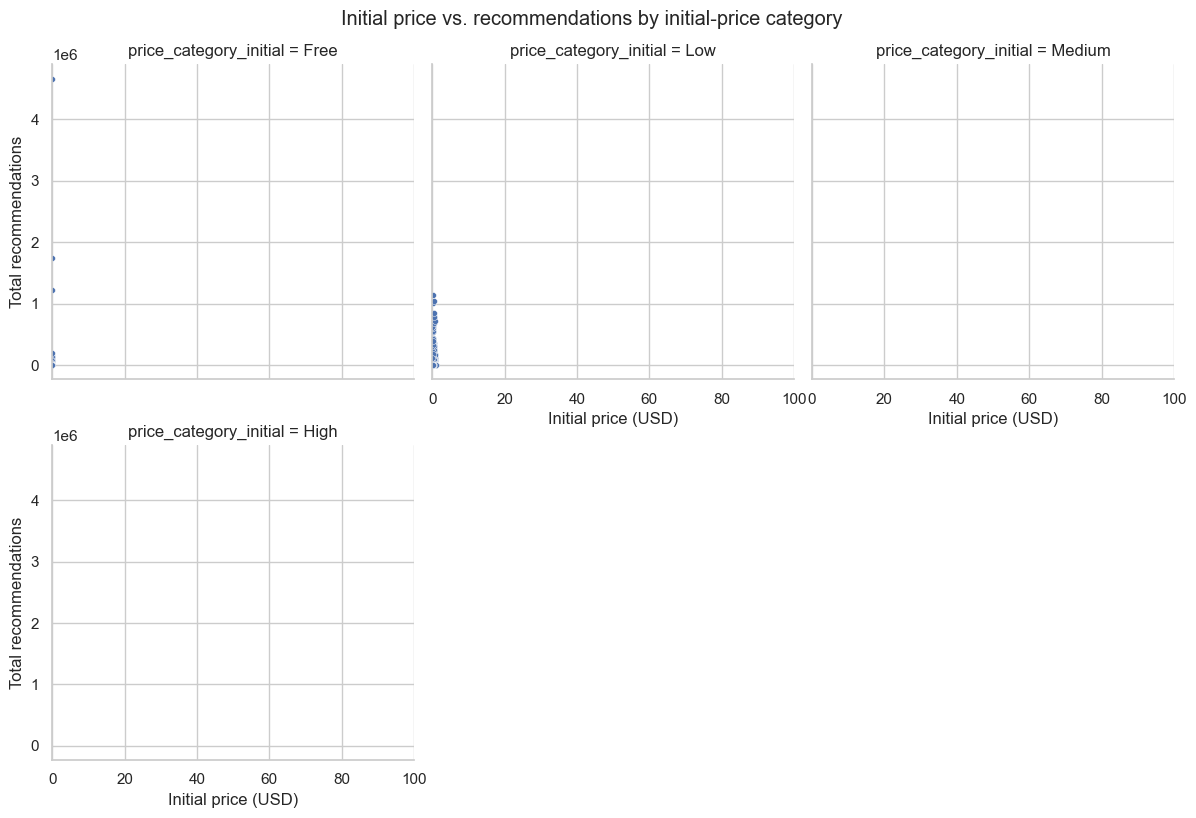

In [ ]:
order = ["Free", "Low", "Medium", "High"]
cat_type = pd.CategoricalDtype(order, ordered=True)
plot_df = games.copy()
plot_df["price_category_initial"] = plot_df["price_category_initial"].astype(cat_type)

g = sns.relplot(
    data=plot_df,
    x="mat_initial_price",
    y="recommendations_total",
    col="price_category_initial",
    kind="scatter",
    col_wrap=3,
    height=4,
    s=18,
)
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_xlim(0, 100)
g.fig.suptitle("Initial price vs. recommendations by initial-price category", y=1.02)
g.set_axis_labels("Initial price (USD)", "Total recommendations")
plt.show()

## Linear trend: initial price vs. recommendations (filtered)

**Question:** After capping extreme list prices and very high recommendation counts, how strong is the **linear** association? *(P1 `lmplot`.)*

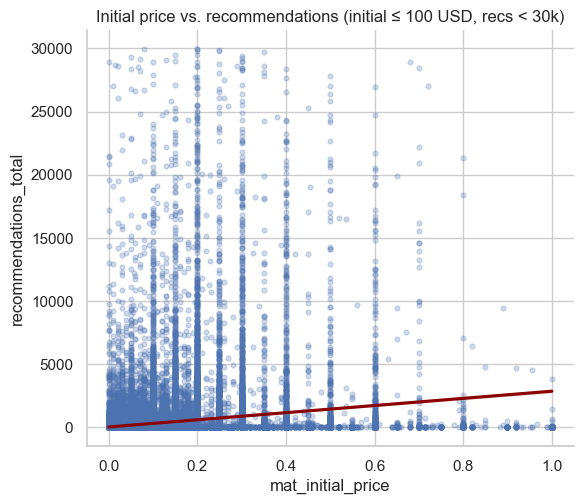

In [ ]:
lm_df = games.query("mat_initial_price <= 100 & recommendations_total < 30000").copy()
sns.lmplot(
    data=lm_df,
    x="mat_initial_price",
    y="recommendations_total",
    scatter_kws={"alpha": 0.25, "s": 12},
    line_kws={"color": "darkred"},
    height=5,
    aspect=1.2,
)
plt.title("Initial price vs. recommendations (initial ≤ 100 USD, recs < 30k)")
plt.show()

## Pairwise numeric relationships (including prices)

**Question:** How do **price, Metacritic, and recommendations** covary pairwise? *(P1 `pairplot` on numeric columns.)*

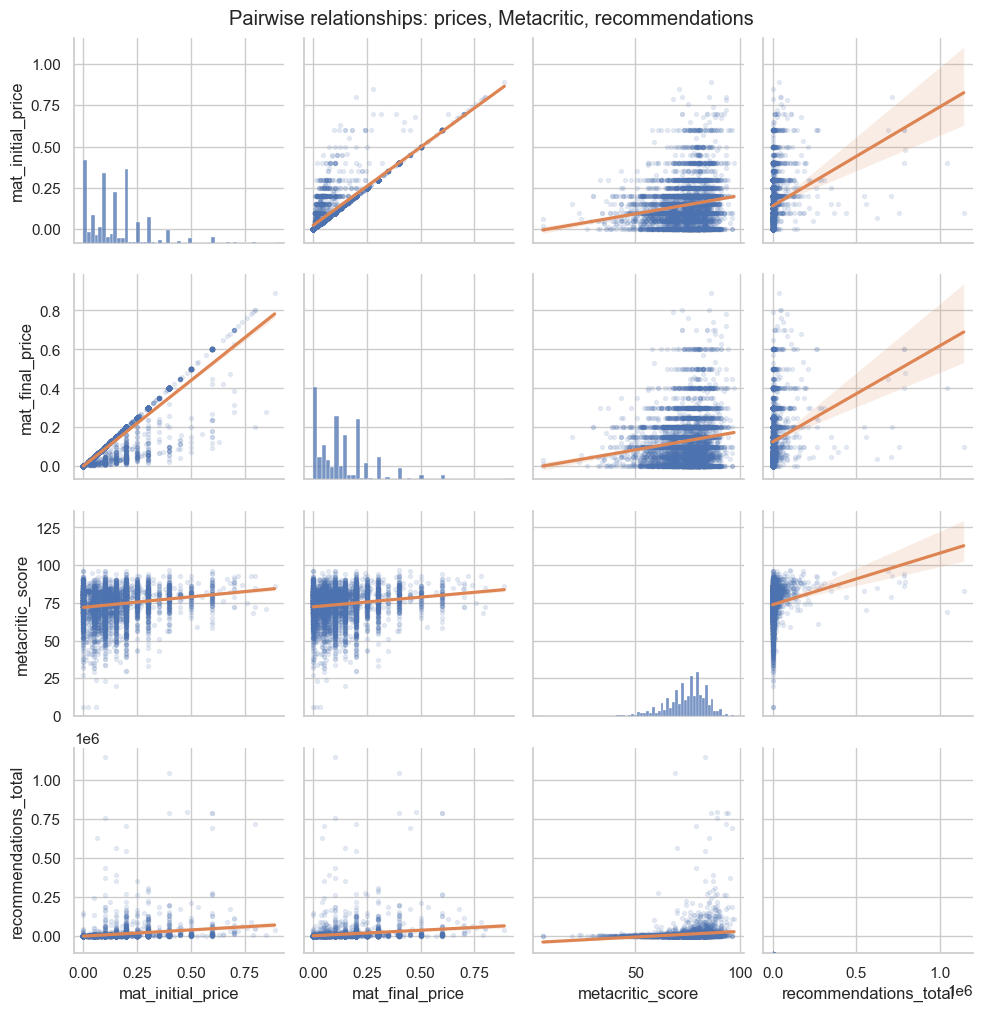

In [ ]:
pair_cols = [
    c
    for c in (
        "mat_initial_price",
        "mat_final_price",
        "metacritic_score",
        "recommendations_total",
    )
    if c in games.columns
]
pair_df = games[pair_cols].apply(pd.to_numeric, errors="coerce")
pair_clean = pair_df.dropna()
if len(pair_clean) < 50:
    print("Skipping pairplot: not enough rows with all core numeric fields.")
else:
    pg = sns.pairplot(
        pair_clean,
        kind="reg",
        plot_kws={"scatter_kws": {"alpha": 0.12, "s": 8}, "line_kws": {"color": "C1"}},
    )
    pg.fig.suptitle("Pairwise relationships: prices, Metacritic, recommendations", y=1.01)
    plt.show()

## Metacritic vs. final-price band

**Question:** Do **Metacritic** score distributions differ across **final-price** tiers? *(P2 boxplot bins.)*

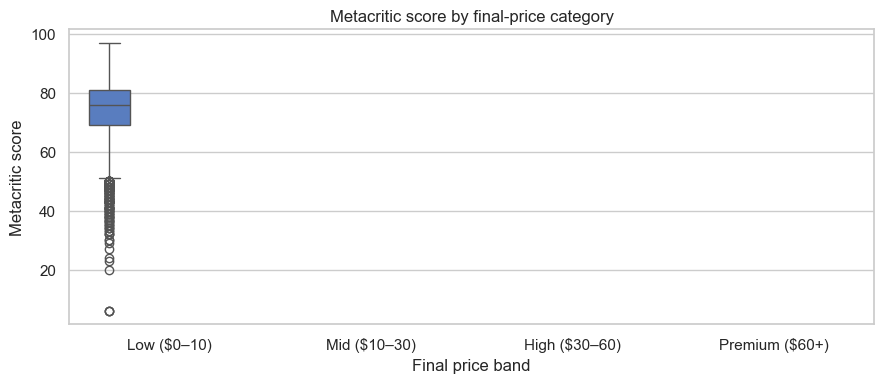

In [ ]:
box_df = games.dropna(subset=["metacritic_score", "price_category_final"]).copy()
plt.figure(figsize=(9, 4))
sns.boxplot(
    data=box_df,
    x="price_category_final",
    y="metacritic_score",
    hue="price_category_final",
    palette="muted",
    legend=False,
)
plt.title("Metacritic score by final-price category")
plt.xlabel("Final price band")
plt.ylabel("Metacritic score")
plt.tight_layout()
plt.show()

## Discount depth vs. average recommendations

**Question:** For games with a **list discount** (`initial − final`), do **mean recommendations** differ by discount size? *(P2 `apply` + bar chart.)*

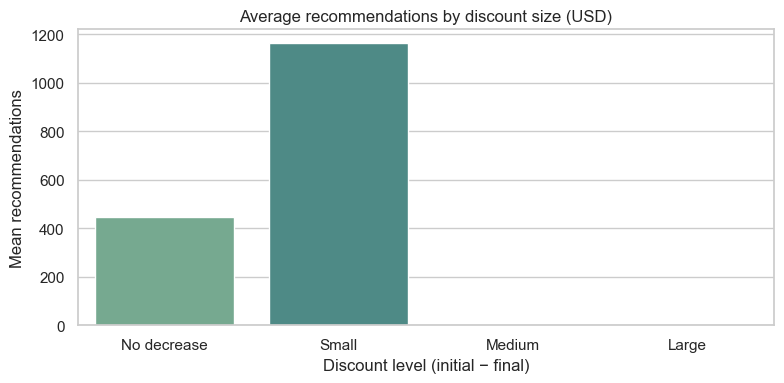

In [ ]:
disc = games.copy()
disc["discount_amount"] = disc["mat_initial_price"] - disc["mat_final_price"]


def discount_level(x: float) -> str:
    if x <= 0:
        return "No decrease"
    if x < 10:
        return "Small"
    if x < 30:
        return "Medium"
    return "Large"


disc["discount_level"] = disc["discount_amount"].apply(discount_level)
order_d = ["No decrease", "Small", "Medium", "Large"]
avg_recs = (
    disc.dropna(subset=["recommendations_total"])
    .groupby("discount_level", observed=False)["recommendations_total"]
    .mean()
    .reindex(order_d)
    .reset_index()
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=avg_recs,
    x="discount_level",
    y="recommendations_total",
    order=order_d,
    hue="discount_level",
    palette="crest",
    legend=False,
)
plt.title("Average recommendations by discount size (USD)")
plt.xlabel("Discount level (initial − final)")
plt.ylabel("Mean recommendations")
plt.tight_layout()
plt.show()

## Candidate predictors of **final** price (static panel)

**Question:** Which simple numeric signals line up most clearly with **final price** in a scatter? *(Mirrors P3 dropdown idea: Metacritic, recommendations, initial price.)*

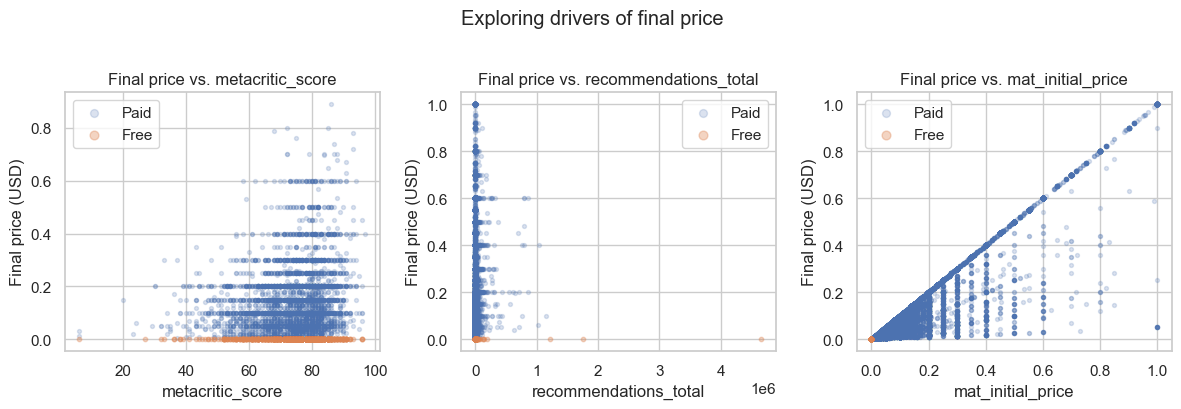

In [ ]:
features = [
    c
    for c in ["metacritic_score", "recommendations_total", "mat_initial_price"]
    if c in games.columns
]
fig, axes = plt.subplots(1, len(features), figsize=(4 * len(features), 4), squeeze=False)
for ax, feat in zip(axes[0], features):
    sub = games[[feat, "mat_final_price", "is_free"]].dropna(subset=[feat, "mat_final_price"])
    free = sub["is_free"] == True
    ax.scatter(sub.loc[~free, feat], sub.loc[~free, "mat_final_price"], alpha=0.2, s=8, label="Paid")
    ax.scatter(sub.loc[free, feat], sub.loc[free, "mat_final_price"], alpha=0.35, s=10, label="Free")
    ax.set_xlabel(feat)
    ax.set_ylabel("Final price (USD)")
    ax.set_title(f"Final price vs. {feat}")
    ax.legend(markerscale=2)
fig.suptitle("Exploring drivers of final price", y=1.02)
plt.tight_layout()
plt.show()